# House Prices — разведочный анализ

Что смотрим:

1. что вообще в данных и где пропуски
2. распределение цены и почему её логарифмируют
3. как цена связана с качеством, площадью, возрастом и районом
4. выбросы
5. что дают признаки из `src/features.py`
6. быстрый baseline, чтобы было с чем сравнивать

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# чтобы работали импорты из src/ независимо от того, откуда запущен ноутбук
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 90)
plt.rcParams["figure.figsize"] = (10, 4)

train = pd.read_csv(ROOT / "data" / "raw" / "train.csv")
test = pd.read_csv(ROOT / "data" / "raw" / "test.csv")
target = "SalePrice"
print(train.shape, test.shape)
train.head()

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Что в данных

In [2]:
numeric = train.select_dtypes("number").columns.drop(["Id", target])
categorical = train.columns.difference(numeric).drop(["Id", target])
print(f"числовых колонок: {len(numeric)}, категориальных: {len(categorical)}")
train[numeric].describe().T

числовых колонок: 36, категориальных: 43


,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


### Пропуски

Пропусков много, но почти все они не «неизвестно», а «этого нет»: `PoolQC` пуст,
когда нет бассейна, `GarageType` — когда нет гаража, и так далее (это написано в
`data_description.txt`). Поэтому в `src/features.py` оценки качества при пропуске
становятся 0, а категории — отдельным значением `missing`. По-настоящему неизвестен
в основном `LotFrontage`.

In [3]:
missing = pd.DataFrame(
    {
        "train_%": train.isna().mean().mul(100).round(1),
        "test_%": test.isna().mean().mul(100).round(1),
    }
).query("`train_%` > 0 or `test_%` > 0")
missing.sort_values("test_%", ascending=False)

,train_%,test_%
PoolQC,99.5,99.8
MiscFeature,96.3,96.5
Alley,93.8,92.7
Fence,80.8,80.1
MasVnrType,59.7,61.3
FireplaceQu,47.3,50.0
LotFrontage,17.7,15.6
GarageFinish,5.5,5.3
GarageCond,5.5,5.3
GarageYrBlt,5.5,5.3


В тесте пропуски есть в колонках, где в train их не было (`MSZoning`, `BsmtFullBath`,
`GarageCars`, ...): по одной-две строки. Поэтому препроцессор заполняет пропуски
во всех колонках, а не только в «известных».

## 2. Целевая переменная

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

скошенность: 1.88, после log1p: 0.12


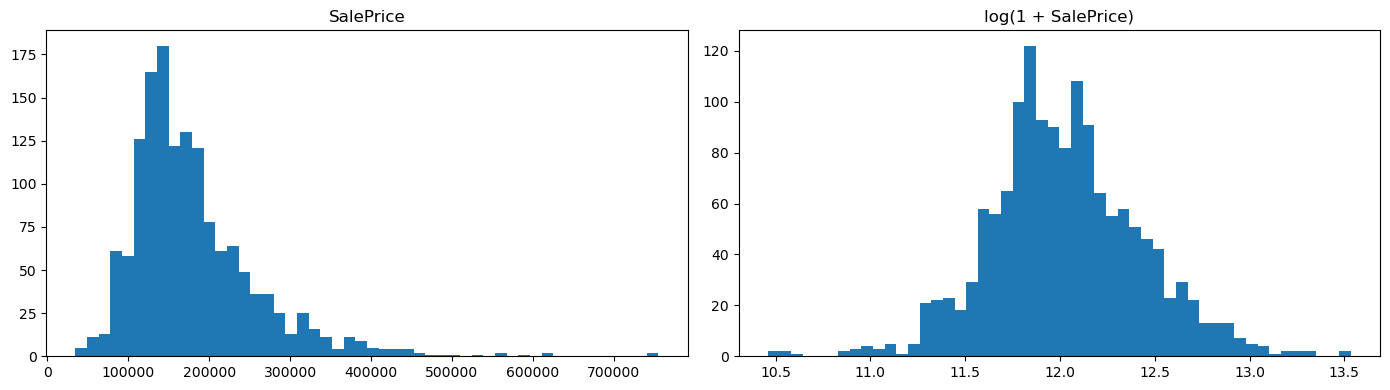

In [4]:
print(train[target].describe().round(0))
print(f"\nскошенность: {train[target].skew():.2f}, после log1p: {np.log1p(train[target]).skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train[target], bins=50)
axes[0].set_title("SalePrice")
axes[1].hist(np.log1p(train[target]), bins=50)
axes[1].set_title("log(1 + SalePrice)")
plt.tight_layout()
plt.show()

Цена сильно скошена вправо: немного очень дорогих домов. После логарифма
распределение почти симметричное. Метрика Kaggle — RMSE между логарифмами цен,
поэтому модель и учится на `log1p(SalePrice)` (`target_log: true` в конфиге):
ошибка в 10% на дешёвом и дорогом доме весит одинаково.

## 3. От чего зависит цена

In [5]:
log_price = np.log1p(train[target])
corr = train[numeric].corrwith(log_price).sort_values(ascending=False)
pd.concat([corr.head(12), corr.tail(5)]).round(3)

OverallQual      0.817
GrLivArea        0.701
GarageCars       0.681
GarageArea       0.651
TotalBsmtSF      0.612
1stFlrSF         0.597
FullBath         0.595
YearBuilt        0.587
YearRemodAdd     0.566
GarageYrBlt      0.541
TotRmsAbvGrd     0.534
Fireplaces       0.489
YrSold          -0.037
LowQualFinSF    -0.038
MSSubClass      -0.074
KitchenAbvGr    -0.148
EnclosedPorch   -0.149
dtype: float64

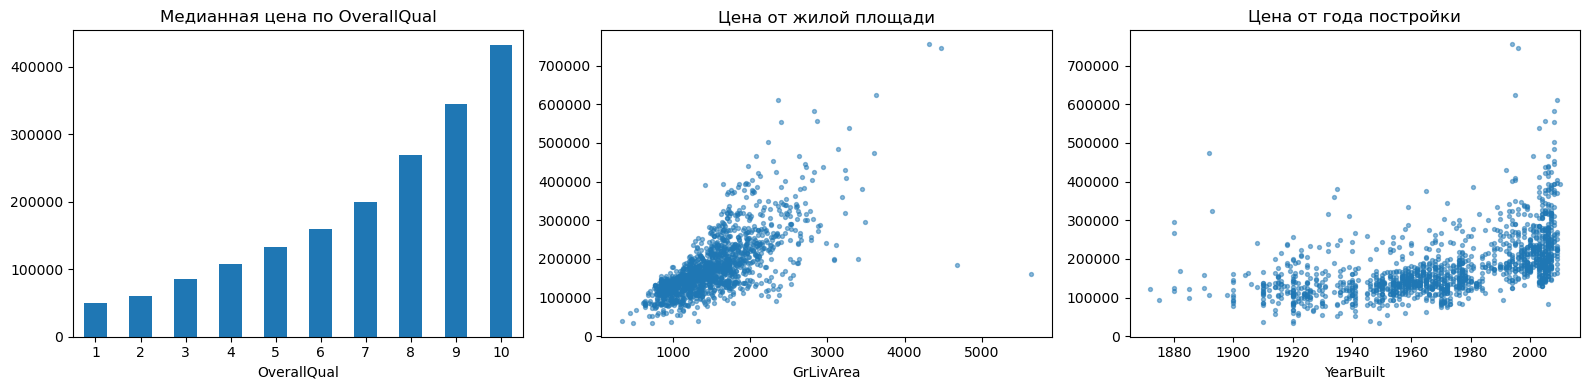

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

train.groupby("OverallQual")[target].median().plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Медианная цена по OverallQual")

axes[1].scatter(train["GrLivArea"], train[target], s=8, alpha=0.5)
axes[1].set_title("Цена от жилой площади")
axes[1].set_xlabel("GrLivArea")

axes[2].scatter(train["YearBuilt"], train[target], s=8, alpha=0.5)
axes[2].set_title("Цена от года постройки")
axes[2].set_xlabel("YearBuilt")

plt.tight_layout()
plt.show()

`OverallQual` — самый сильный одиночный признак, и зависимость от него явно
нелинейная (каждая следующая ступень дороже предыдущей) — в логарифмах она
выпрямляется. Площадь идёт второй. Справа на графике площади видны точки,
которые выбиваются из общего облака, — о них ниже.

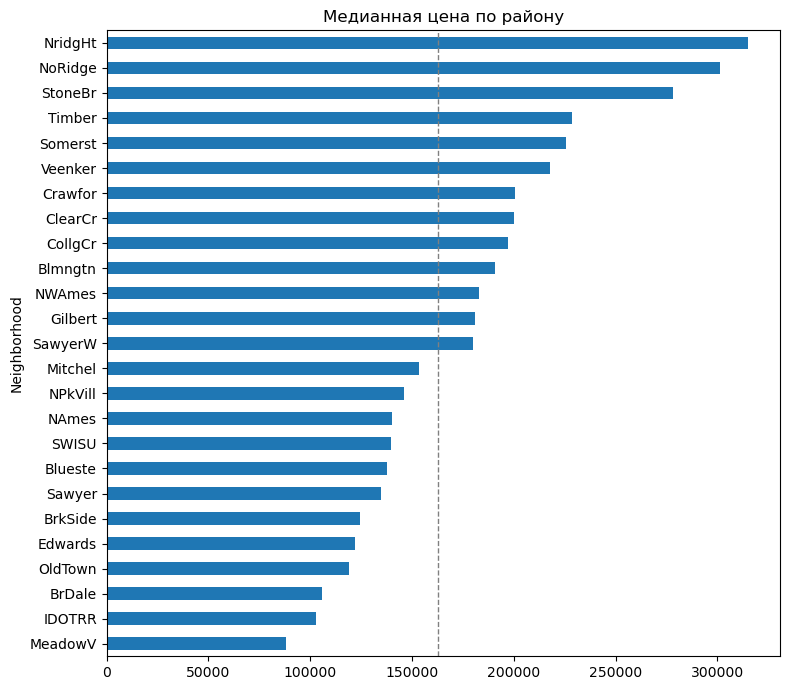

In [7]:
by_hood = train.groupby("Neighborhood")[target].agg(["median", "count"]).sort_values("median")
by_hood["median"].plot(kind="barh", figsize=(8, 7), title="Медианная цена по району")
plt.axvline(train[target].median(), color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

Разница между районами — в разы. Район — категориальный признак с 25 значениями:
деревья справляются с ним через ordinal-кодирование, линейные модели — через onehot.

## 4. Выбросы

In [8]:
huge = train["GrLivArea"] > 4000
train.loc[huge, ["Id", "GrLivArea", "OverallQual", "Neighborhood", "SaleCondition", target]]

,Id,GrLivArea,OverallQual,Neighborhood,SaleCondition,SalePrice
523,524,4676,10,Edwards,Partial,184750
691,692,4316,10,NoRidge,Normal,755000
1182,1183,4476,10,NoRidge,Abnorml,745000
1298,1299,5642,10,Edwards,Partial,160000


Четыре дома больше 4000 кв. футов. Два из них стоят как средний дом — это частичные
продажи (`SaleCondition=Partial`) в одном районе. Автор датасета сам советует
убирать дома больше 4000 кв. футов. Мы убираем только эти два
(`data.drop_outliers: true`) и только из train.

Для линейной модели это критично: без удаления lasso даёт 0.1425 вместо 0.1094
(см. `RESULTS.md`). В тесте есть похожий дом (`Id=2550`) — на нём модель, скорее
всего, ошибётся, и с этим ничего не поделать.

## 5. Признаки из src/features.py

In [9]:
from src.features import add_features

featured = add_features(train.drop(columns=["Id"]))
new_columns = sorted(set(featured.columns) - set(train.columns))
print("новые колонки:", new_columns)
featured[new_columns + ["OverallQual", "ExterQual", "KitchenQual"]].head()

новые колонки: ['Has2ndFlr', 'HasBsmt', 'HasFireplace', 'HasGarage', 'HasPool', 'HouseAge', 'IsRemodeled', 'QualLivArea', 'RemodAge', 'TotalBath', 'TotalPorchSF', 'TotalSF']


,Has2ndFlr,HasBsmt,HasFireplace,HasGarage,HasPool,HouseAge,IsRemodeled,QualLivArea,RemodAge,TotalBath,TotalPorchSF,TotalSF,OverallQual,ExterQual,KitchenQual
0,1,1,0,1,0,5,0,11970,5,3.5,4.127134,7.850493,7,4,4
1,0,1,1,1,0,31,0,7572,31,2.5,5.700444,7.833996,6,3,3
2,1,1,1,1,0,7,1,12502,6,3.5,3.761200,7.903596,7,4,4
3,1,1,1,1,0,91,1,12019,36,2.0,5.730100,7.813592,7,3,4
4,1,1,1,1,0,8,0,17584,8,3.5,5.624018,8.114923,8,4,4


In [10]:
featured_numeric = featured.select_dtypes("number").drop(columns=[target])
featured_corr = featured_numeric.corrwith(np.log1p(featured[target])).sort_values(ascending=False)
featured_corr.head(15).round(3)

OverallQual     0.817
TotalSF         0.807
QualLivArea     0.800
GrLivArea       0.730
GarageCars      0.681
ExterQual       0.679
TotalBath       0.673
KitchenQual     0.668
GarageArea      0.651
BsmtQual        0.616
TotalBsmtSF     0.612
1stFlrSF        0.609
GarageFinish    0.605
FullBath        0.595
YearBuilt       0.587
dtype: float64

На что смотреть: `TotalSF` (общая площадь с подвалом) и `QualLivArea`
(качество × площадь) почти догоняют `OverallQual` и заметно сильнее любой
исходной площади (`GrLivArea` ~0.73). Оценки качества
(`ExterQual`, `KitchenQual`, ...) после перевода в числа 0–5 тоже попадают в верх
таблицы — в исходном виде это были строки, и корреляцию по ним не посчитать.

Корреляция линейная, так что низкое значение не значит «признак бесполезен».

## 6. Baseline

In [11]:
import yaml

from src.training import train as run_training

with open(ROOT / "config.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg["model"]["name"] = "lasso"
cfg["features"]["encoding"] = "onehot"
cfg["features"]["scale"] = True
cfg["output_dir"] = str(ROOT / "outputs")
cfg["data"]["train_path"] = str(ROOT / "data" / "raw" / "train.csv")
cfg["data"]["test_path"] = str(ROOT / "data" / "raw" / "test.csv")

metrics = run_training(cfg)
metrics

удалено выбросов: 2
train: (1458, 79), test: (1459, 79)
признаков: 62 числовых, 28 категориальных
fold 1/5: rmse_log=0.1083, rmse=18238.9168, mae=12904.7344, r2=0.9398
fold 2/5: rmse_log=0.1087, rmse=18471.5644, mae=12830.7347, r2=0.9514
fold 3/5: rmse_log=0.1183, rmse=19701.8315, mae=13522.1423, r2=0.9272
fold 4/5: rmse_log=0.1111, rmse=19622.1829, mae=13123.6655, r2=0.9468
fold 5/5: rmse_log=0.0998, rmse=23391.9171, mae=13809.6211, r2=0.9151

OOF: rmse_log=0.1094, rmse=19968.8231, mae=13237.8662, r2=0.9369
  rmse_log: 0.1092 +- 0.0059 по фолдам
  rmse: 19885.2825 +- 1849.7827 по фолдам
  mae: 13238.1796 +- 373.4945 по фолдам
  r2: 0.9361 +- 0.0133 по фолдам

Результаты: c:\Users\mkizo\ml\house-prices\outputs\2026-09-27_20-02-37_lasso


{'rmse_log': 0.10939051331853532,
 'rmse': 19968.823073164545,
 'mae': 13237.866219382979,
 'r2': 0.936857368268672}

Дальше эксперименты удобнее гонять из терминала — там же они и логируются:

```bash
python main.py train --set model.name=lgbm
python main.py train --set model.name=ridge --set features.encoding=onehot --set features.scale=true
```

Результаты сравнений записывайте в `RESULTS.md`.

## Выводы

Заполните по итогам своего анализа — например:

- цена определяется в первую очередь качеством, площадью и районом;
- логарифм цены обязателен — и из-за скошенности, и из-за метрики;
- два выброса в train стоит удалить, иначе линейные модели разваливаются;
- что попробовать дальше: ...